In [5]:


import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import brentq
from PIL import Image

## 误差和不确定性区域联系在一起了！
def CI_fwer(scores, masks, alpha=0.05):
    """
    Calculate the threshold for family-wise error rate (FWER) in conformal inference.
    Parameters:
    scores (ndarray): 3D array of statistical scores where the last dimension represents different images.
    masks (ndarray): 3D binary array indicating the mask for each image, matching the scores array.
    alpha (float): Significance level for FWER.
    Returns:
    tuple: threshold for FWER, array of maximum values per image after masking.
    """
    nimages = scores.shape[-1]
    max_vals = np.zeros(nimages) # max_vals 用来存储每个样本在非掩码区域的最大分数。

    for i in range(nimages):
        # masked_image = scores[..., i] * (1 - masks[..., i].astype(float)) # 原始代码有问题,可能是python不能兼容的原因
        masked_image = np.nan_to_num(scores[..., i] * (1 - masks[..., i].astype(float)), nan=0.0, posinf=0.0, neginf=0.0)
        #这种方式将 NaN 和极端值（inf 和 -inf）替换为 0，从而避免了绘图或计算过程中出现问题。
        max_vals[i] = masked_image.max()
        # print(max_vals[i])
    threshold = np.percentile(max_vals, 100 * (1 - alpha))  
    
    # 绘制 max_vals 的分布和阈值
    plt.figure(figsize=(10, 6))
    plt.hist(max_vals, bins=30, color='skyblue', edgecolor='black', density=True)
    plt.axvline(threshold, color='red', linestyle='--', label=f'{(1 - alpha) * 100}% Threshold: {threshold:.2f}')
    plt.xlabel('Max values')
    plt.ylabel('Density')
    plt.title(f'Distribution of Maximum Values (Threshold at {100 * (1 - alpha)}th percentile)')
    plt.legend()
    plt.show()
    
    return threshold, max_vals

def CI_fwer_topo(scores, masks, alpha1, alpha2):
    """
    Calculate the threshold for family-wise error rate (FWER) in conformal inference.
    """
    nimages = scores.shape[-1]
    min_vals = np.zeros(nimages)
    all_topo_probs = []  # 用于收集所有样本的topo_mask区域的概率值

    for i in range(nimages):  # 遍历所有图像
        # 计算漏检区域
        gt_mask = masks[..., i].astype(float)
        pred_mask = (scores[..., i] > 0.6).astype(float)
        missed_regions = np.clip(gt_mask - pred_mask, 0, 1)
        
        # 提取骨架
        from skimage.morphology import skeletonize
        gt_mask_binary = (gt_mask > 0).astype(np.uint8)
        # skeleton = skeletonize(gt_mask_binary)
        
        # 获取missed_regions和skeleton的重叠区域
        topo_mask = (missed_regions > 0) & gt_mask_binary
        
        # 收集当前样本topo_mask区域的概率值
        # 收集当前样本topo_mask区域的非零概率值
        mask_probs = scores[..., i][topo_mask]
        # 只保留非零的概率值
        non_zero_probs = mask_probs[mask_probs>=0] # 只有当有非零概率值时才添加
        if len(non_zero_probs) > 0: 
            all_topo_probs.extend(non_zero_probs)
        
        # 计算最终的masked_image
        masked_image = np.nan_to_num(scores[..., i] * topo_mask, nan=0.0, posinf=0.0, neginf=0.0)
        min_vals[i] = masked_image.min()
    print(f'all_topo_probs最小值: {min(all_topo_probs)}')
    # 将所有概率值转换为numpy数组
    all_topo_probs = np.array(all_topo_probs)
    
    # 绘制所有样本topo_mask区域的概率分布
    plt.figure(figsize=(10, 6))
    plt.hist(all_topo_probs, bins=100, color='skyblue', edgecolor='black', density=True)
    plt.xlabel('Probability')
    plt.ylabel('Density')
    plt.title('Probability Distribution in All Topology Mask Regions')
    plt.show()

    return all_topo_probs

# 风险控制最初版本
def false_positive_rate(pred_masks, true_masks):
    """
    Calculate the False Positive Rate (FPR)
    
    Parameters:
    - pred_masks: binary predicted masks, shape (H, W, N)
    - true_masks: ground truth masks, shape (H, W, N)
    
    Returns:
    - float: the average False Positive Rate
    """
    assert pred_masks.shape == true_masks.shape
    
    # 计算FPR：FP / (FP + TN)
    fp = ((pred_masks == 1) & (true_masks == 0)).sum(axis=(0, 1))
    tn = ((pred_masks == 0) & (true_masks == 0)).sum(axis=(0, 1))
    fpr = fp / (fp + tn)
    return fpr.mean()

def false_negative_rate(pred_masks, true_masks):
    """
    Calculate the False Negative Rate (FNR)
    
    Parameters:
    - pred_masks: binary predicted masks, shape (H, W, N)
    - true_masks: ground truth masks, shape (H, W, N)
    
    Returns:
    - float: the average False Negative Rate
    """
    assert pred_masks.shape == true_masks.shape
    
    # 计算FNR：FN / (FN + TP)
    fn = ((pred_masks == 0) & (true_masks == 1)).sum(axis=(0, 1))
    tp = ((pred_masks == 1) & (true_masks == 1)).sum(axis=(0, 1))
    fnr = fn / (fn + tp)
    return fnr.mean()

# Define lamhat threshold function（闭包形式）
def create_lamhat_threshold_FNR(cal_scores, cal_gt_masks, n, alpha):
    def lamhat_threshold(lam):
        pred_masks = cal_scores >= lam
        return false_negative_rate(pred_masks, cal_gt_masks) - ((n + 1) / n * alpha - 1 / n)
    return lamhat_threshold

# Define lamhat threshold function（闭包形式）
def create_lamhat_threshold_FPR(cal_scores, cal_gt_masks, n, alpha):
    def lamhat_threshold(lam):
        pred_masks = cal_scores >= lam
        return false_positive_rate(pred_masks, cal_gt_masks) - ((n + 1) / n * alpha - 1 / n)
    return lamhat_threshold

# 加载测试数据
cal_masks_path = '/home/xkw/pxlames/segmentation/outputs/testResults/FIVE-BceDiceSmooth_0.0001_4/cal_gt_masks.npy'
cal_scores_path = '/home/xkw/pxlames/segmentation/outputs/testResults/FIVE-BceDiceSmooth_0.0001_4/cal_scores.npy'
test_masks_path = '/home/xkw/pxlames/segmentation/outputs/testResults/FIVE-BceDiceSmooth_0.0001_4/gt_masks.npy'
test_scores_path = '/home/xkw/pxlames/segmentation/outputs/testResults/FIVE-BceDiceSmooth_0.0001_4/scores.npy'
train_scores_path = '/home/xkw/pxlames/segmentation/outputs/testResults/FIVE-BceDiceSmooth_0.0001_4/train_scores.npy'
train_masks_path = '/home/xkw/pxlames/segmentation/outputs/testResults/FIVE-BceDiceSmooth_0.0001_4/train_gt_masks.npy'
cal_masks = np.load(cal_masks_path)
cal_scores = np.load(cal_scores_path)
test_masks = np.load(test_masks_path)
test_scores = np.load(test_scores_path)
train_masks = np.load(train_masks_path)
train_scores = np.load(train_scores_path)
# 重塑数组
cal_masks = np.transpose(cal_masks, (1, 2, 0))
cal_scores = np.transpose(cal_scores, (1, 2, 0))
test_masks = np.transpose(test_masks, (1, 2, 0))
test_scores = np.transpose(test_scores, (1, 2, 0))
train_masks = np.transpose(train_masks, (1, 2, 0))
train_scores = np.transpose(train_scores, (1, 2, 0))
print("成功加载gt_masks和scores文件")

成功加载gt_masks和scores文件


Calculated lamhat threshold: 0.018461889588091925
Single image shape: (2048, 2048)
Unique values: [  0 255]


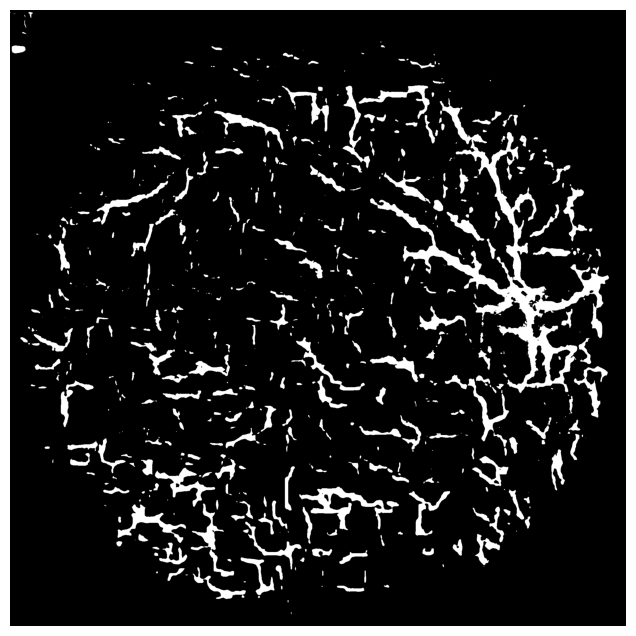

Single image shape: (2048, 2048)
Unique values: [  0 255]
Single image shape: (2048, 2048)
Unique values: [  0 255]
Single image shape: (2048, 2048)
Unique values: [  0 255]
Single image shape: (2048, 2048)
Unique values: [  0 255]
Single image shape: (2048, 2048)
Unique values: [  0 255]
Single image shape: (2048, 2048)
Unique values: [  0 255]
Single image shape: (2048, 2048)
Unique values: [  0 255]
Single image shape: (2048, 2048)
Unique values: [  0 255]
Single image shape: (2048, 2048)
Unique values: [  0 255]
Single image shape: (2048, 2048)
Unique values: [  0 255]
Single image shape: (2048, 2048)
Unique values: [  0 255]
Single image shape: (2048, 2048)
Unique values: [  0 255]
Single image shape: (2048, 2048)
Unique values: [  0 255]
Single image shape: (2048, 2048)
Unique values: [  0 255]
Single image shape: (2048, 2048)
Unique values: [  0 255]
Single image shape: (2048, 2048)
Unique values: [  0 255]
Single image shape: (2048, 2048)
Unique values: [  0 255]
Single image s

In [6]:
# 使用方法
threshold_func = create_lamhat_threshold_FNR(cal_scores, cal_masks, cal_scores.shape[0], 0.05)
lamhat = brentq(threshold_func, 0, 1)
print(f"Calculated lamhat threshold: {lamhat}")

saveDir = '/home/xkw/pxlames/segmentation/outputs/firstStageResults/FIVE-BceDiceSmooth_0.0001_4/FIVE/train'
for i in range(train_scores.shape[2]):  
    # 提取单个2D图像 (2048, 2048)
    test_result = train_scores[:, :, i]  
    test_result_certain = (test_result > lamhat).astype(np.uint8) * 255
    
    print("Single image shape:", test_result_certain.shape)
    print("Unique values:", np.unique(test_result_certain))
    
    # 保存图像
    img = Image.fromarray(test_result_certain)
    save_path = os.path.join(saveDir, f"U_{i+1}.png")
    img.save(save_path)
    
    # 显示第一张图像
    if i == 0:
        plt.figure(figsize=(8, 8))
        plt.imshow(test_result_certain, cmap='gray')
        plt.axis('off')
        plt.show()

Calculated lamhat threshold: 0.8983931839466262
Single image shape: (2048, 2048)
Unique values: [  0 255]


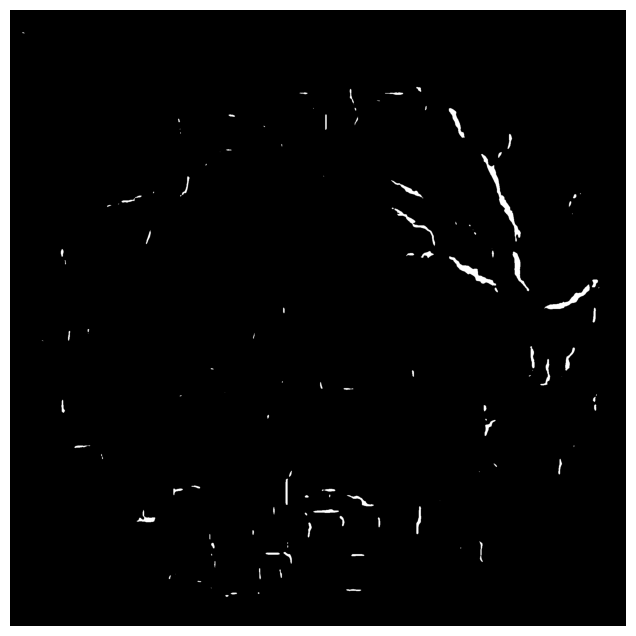

Single image shape: (2048, 2048)
Unique values: [  0 255]
Single image shape: (2048, 2048)
Unique values: [  0 255]
Single image shape: (2048, 2048)
Unique values: [  0 255]
Single image shape: (2048, 2048)
Unique values: [  0 255]
Single image shape: (2048, 2048)
Unique values: [  0 255]
Single image shape: (2048, 2048)
Unique values: [  0 255]
Single image shape: (2048, 2048)
Unique values: [  0 255]
Single image shape: (2048, 2048)
Unique values: [  0 255]
Single image shape: (2048, 2048)
Unique values: [  0 255]
Single image shape: (2048, 2048)
Unique values: [  0 255]
Single image shape: (2048, 2048)
Unique values: [  0 255]
Single image shape: (2048, 2048)
Unique values: [  0 255]
Single image shape: (2048, 2048)
Unique values: [  0 255]
Single image shape: (2048, 2048)
Unique values: [  0 255]
Single image shape: (2048, 2048)
Unique values: [  0 255]
Single image shape: (2048, 2048)
Unique values: [  0 255]
Single image shape: (2048, 2048)
Unique values: [  0 255]
Single image s

In [7]:
# 使用方法
threshold_func = create_lamhat_threshold_FPR(cal_scores, cal_masks, cal_scores.shape[0], 0.005)
lamhat = brentq(threshold_func, 0, 1)
print(f"Calculated lamhat threshold: {lamhat}")

saveDir = '/home/xkw/pxlames/segmentation/outputs/firstStageResults/FIVE-BceDiceSmooth_0.0001_4/FIVE/train'
for i in range(train_scores.shape[2]):  
    # 提取单个2D图像 (2048, 2048)
    test_result = train_scores[:, :, i]  
    test_result_certain = (test_result > lamhat).astype(np.uint8) * 255
    
    print("Single image shape:", test_result_certain.shape)
    print("Unique values:", np.unique(test_result_certain))
    
    # 保存图像
    img = Image.fromarray(test_result_certain)
    save_path = os.path.join(saveDir, f"{i+1}.png")
    img.save(save_path)
    
    # 显示第一张图像
    if i == 0:
        plt.figure(figsize=(8, 8))
        plt.imshow(test_result_certain, cmap='gray')
        plt.axis('off')
        plt.show()

In [14]:
import cv2
import os
import matplotlib.pyplot as plt
import numpy as np

def remove_edge_lines(image):
    """
    对图像进行轻微腐蚀，去除边缘细线
    Args:
        image: 输入图像
    Returns:
        处理后的图像
    """
    # 使用小的结构元素
    kernel = np.array([[0,1,0],
                  [1,1,1],
                  [0,1,0]], np.uint8)    
    # 进行单次腐蚀操作
    eroded = cv2.erode(image, kernel, iterations=2)
    
    return eroded

def process_images(read_dir):
    """
    处理图像对并生成差值图像，然后进行轻微腐蚀处理
    Args:
        read_dir: 包含图像的目录路径
    """
    # 创建保存结果的目录
    output_dir = os.path.join(read_dir, 'results_processed')
    os.makedirs(output_dir, exist_ok=True)
        
    for i in range(train_scores.shape[2]):  
            # 构建文件路径
            img1_path = os.path.join(read_dir, f'{i}.png')
            img2_path = os.path.join(read_dir, f'U_{i}.png')
            
            if not (os.path.exists(img1_path) and os.path.exists(img2_path)):
                print(f"找不到图像对 {i}")
                continue
                
            # 读取图像
            img1 = cv2.imread(img1_path, cv2.IMREAD_GRAYSCALE)
            img2 = cv2.imread(img2_path, cv2.IMREAD_GRAYSCALE)
            
            if img1 is None or img2 is None:
                print(f"无法读取图像对 {i}")
                continue
                
            if img1.shape != img2.shape:
                print(f"图像对 {i} 大小不匹配")
                continue
                
            # 计算差值图像
            diff_img = cv2.subtract(img2, img1)
            
            # 轻微腐蚀处理去除边缘细线
            processed_img = remove_edge_lines(diff_img)
            
            # 保存处理后的图像
            output_path = os.path.join(output_dir, f'U_one_{i}_processed.png')
            cv2.imwrite(output_path, processed_img)
            
            # 显示结果比较
            plt.figure(figsize=(20, 5))
            
            plt.subplot(141)
            plt.imshow(img1, cmap='gray')
            plt.title(f'Original {i}.png')
            plt.axis('off')
            
            plt.subplot(142)
            plt.imshow(img2, cmap='gray')
            plt.title(f'U_{i}.png')
            plt.axis('off')
            
            plt.subplot(143)
            plt.imshow(diff_img, cmap='gray')
            plt.title(f'Difference')
            plt.axis('off')
            
            plt.subplot(144)
            plt.imshow(processed_img, cmap='gray')
            plt.title(f'Processed (Light Erosion)')
            plt.axis('off')
            
            # 保存对比图
            plt.savefig(os.path.join(output_dir, f'comparison_{i}.png'))
            plt.close()
            
            print(f"处理完成图像对 {i}")

if __name__ == "__main__":
    read_dir = '/home/xkw/pxlames/segmentation/outputs/firstStageResults/FIVE-BceDiceSmooth_0.0001_4/FIVE/train'
    # read_dir = '/home/xkw/pxlames/segmentation/outputs/firstStageResults/FIVE-BceDiceSmooth_0.0001_4'
    process_images(read_dir)

找不到图像对 0
处理完成图像对 1
处理完成图像对 2
处理完成图像对 3
处理完成图像对 4
处理完成图像对 5
处理完成图像对 6
处理完成图像对 7
处理完成图像对 8
处理完成图像对 9
处理完成图像对 10
处理完成图像对 11
处理完成图像对 12
处理完成图像对 13
处理完成图像对 14
处理完成图像对 15
处理完成图像对 16
处理完成图像对 17
处理完成图像对 18
处理完成图像对 19
处理完成图像对 20
处理完成图像对 21
处理完成图像对 22
处理完成图像对 23
处理完成图像对 24
处理完成图像对 25
处理完成图像对 26
处理完成图像对 27
处理完成图像对 28
处理完成图像对 29
处理完成图像对 30
处理完成图像对 31
处理完成图像对 32
处理完成图像对 33
处理完成图像对 34
处理完成图像对 35
处理完成图像对 36
处理完成图像对 37
处理完成图像对 38
处理完成图像对 39
处理完成图像对 40
处理完成图像对 41
处理完成图像对 42
处理完成图像对 43
处理完成图像对 44
处理完成图像对 45
处理完成图像对 46
处理完成图像对 47
处理完成图像对 48
处理完成图像对 49
处理完成图像对 50
处理完成图像对 51
处理完成图像对 52
处理完成图像对 53
处理完成图像对 54
处理完成图像对 55
处理完成图像对 56
处理完成图像对 57
处理完成图像对 58
处理完成图像对 59
处理完成图像对 60
处理完成图像对 61
处理完成图像对 62
处理完成图像对 63
处理完成图像对 64
处理完成图像对 65
处理完成图像对 66
处理完成图像对 67
处理完成图像对 68
处理完成图像对 69
处理完成图像对 70
处理完成图像对 71
处理完成图像对 72
处理完成图像对 73
处理完成图像对 74
处理完成图像对 75
处理完成图像对 76
处理完成图像对 77
处理完成图像对 78
处理完成图像对 79
处理完成图像对 80
处理完成图像对 81
处理完成图像对 82
处理完成图像对 83
处理完成图像对 84
处理完成图像对 85
处理完成图像对 86
处理完成图像对 87
处理完成图像对 88
处理完成图像对 89
处理完成图像对 90
处理完成图像对 91